In [9]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import re
import sys

import pandas as pd
import scanpy as sc
import seaborn as sns
import torch

candidates = [Path.cwd() / "clean_HYperedge", Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    path for path in candidates
    if (path / "src/cme_supervision.py").exists() and (path / "datasets/adata_672.h5ad").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from src.cme_supervision import (
    build_supervision_from_cme,
    compute_cme_matrix,
    compute_cme_pvalues,
    load_expression_from_h5ad,
)
from src.cme_visualization import plot_cme_supervision_heatmaps
from src.metagene_tree import (
    build_metagene_tree_from_result,
    plot_metagene_tree,
    score_cell_types_from_metagene_tree,
    score_cell_hierarchy_from_cell_types,
    validate_metagene_tree_result,
)
from src.supervision_pipeline import (
    plot_run_summary,
    run_supervised_hyperedges,
    summarize_unassigned_genes,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'adata_path': '/home/luqi/Desktop/GAMULE22/clean_HYperedge/datasets/adata_104.h5ad', 'num_cells': 900, 'num_genes': 150}
{'observed_gene_modules': ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'Root'], 'observed_cell_types': ['A1', 'A2', 'A3', 'B1', 'B2', 'B3']}


Text(50.722222222222214, 0.5, 'Cells')

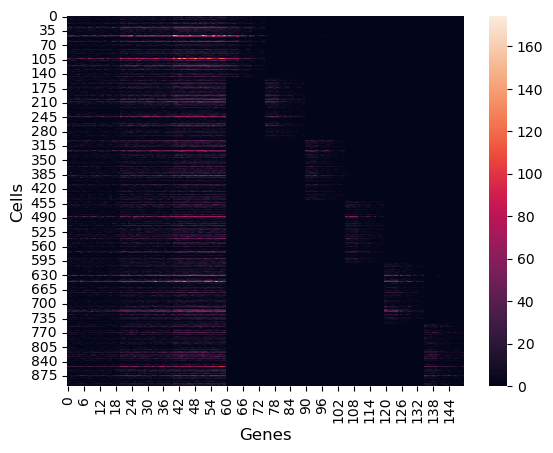

In [10]:
ADATA_PATH = REPO_ROOT / "datasets/adata_104.h5ad"
RESULT_PREFIX = ADATA_PATH.stem

adata = sc.read(ADATA_PATH)
num_cells = int(adata.n_obs)
num_genes = int(adata.n_vars)

print({"adata_path": str(ADATA_PATH), "num_cells": num_cells, "num_genes": num_genes})

def get_gene_module_labels(adata, col_name="gene_module"):
    pattern = re.compile(r"^g(?P<module>[A-Za-z0-9]+)_gb\d+_\d+$")
    labels = []
    for gene in adata.var_names.astype(str):
        match = pattern.match(gene)
        labels.append(match.group("module") if match else "NA")
    return pd.Series(labels, index=adata.var_names, name=col_name)

adata.var["gene_module"] = get_gene_module_labels(adata)
observed_gene_modules = sorted(
    label for label in adata.var["gene_module"].unique().tolist()
    if label not in {"NA", ""}
)
observed_cell_types = sorted(adata.obs["cell_type"].astype(str).unique().tolist()) if "cell_type" in adata.obs else []

print({
    "observed_gene_modules": observed_gene_modules,
    "observed_cell_types": observed_cell_types,
})

ax = sns.heatmap(adata.X)
ax.set_xlabel("Genes", fontsize=12)
ax.set_ylabel("Cells", fontsize=12)

In [11]:
seed = 0

t_CME = 0.66
t_p = 0.05
t_Jaccard = 0.73
k_Jaccard = 100
n_permutations = 20

num_gene_modules = 6
num_gene_modules = max(1, min(num_gene_modules, num_genes))
num_hyperedges = num_gene_modules + 1

torch.manual_seed(seed)

run_config = {
    "seed": seed,
    "t_CME": t_CME,
    "t_p": t_p,
    "t_Jaccard": t_Jaccard,
    "k_Jaccard": k_Jaccard,
    "n_permutations": n_permutations,
    "num_gene_modules": num_gene_modules,
    "num_hyperedges": num_hyperedges,
}
run_config


{'seed': 0,
 't_CME': 0.66,
 't_p': 0.05,
 't_Jaccard': 0.73,
 'k_Jaccard': 100,
 'n_permutations': 20,
 'num_gene_modules': 6,
 'num_hyperedges': 7}

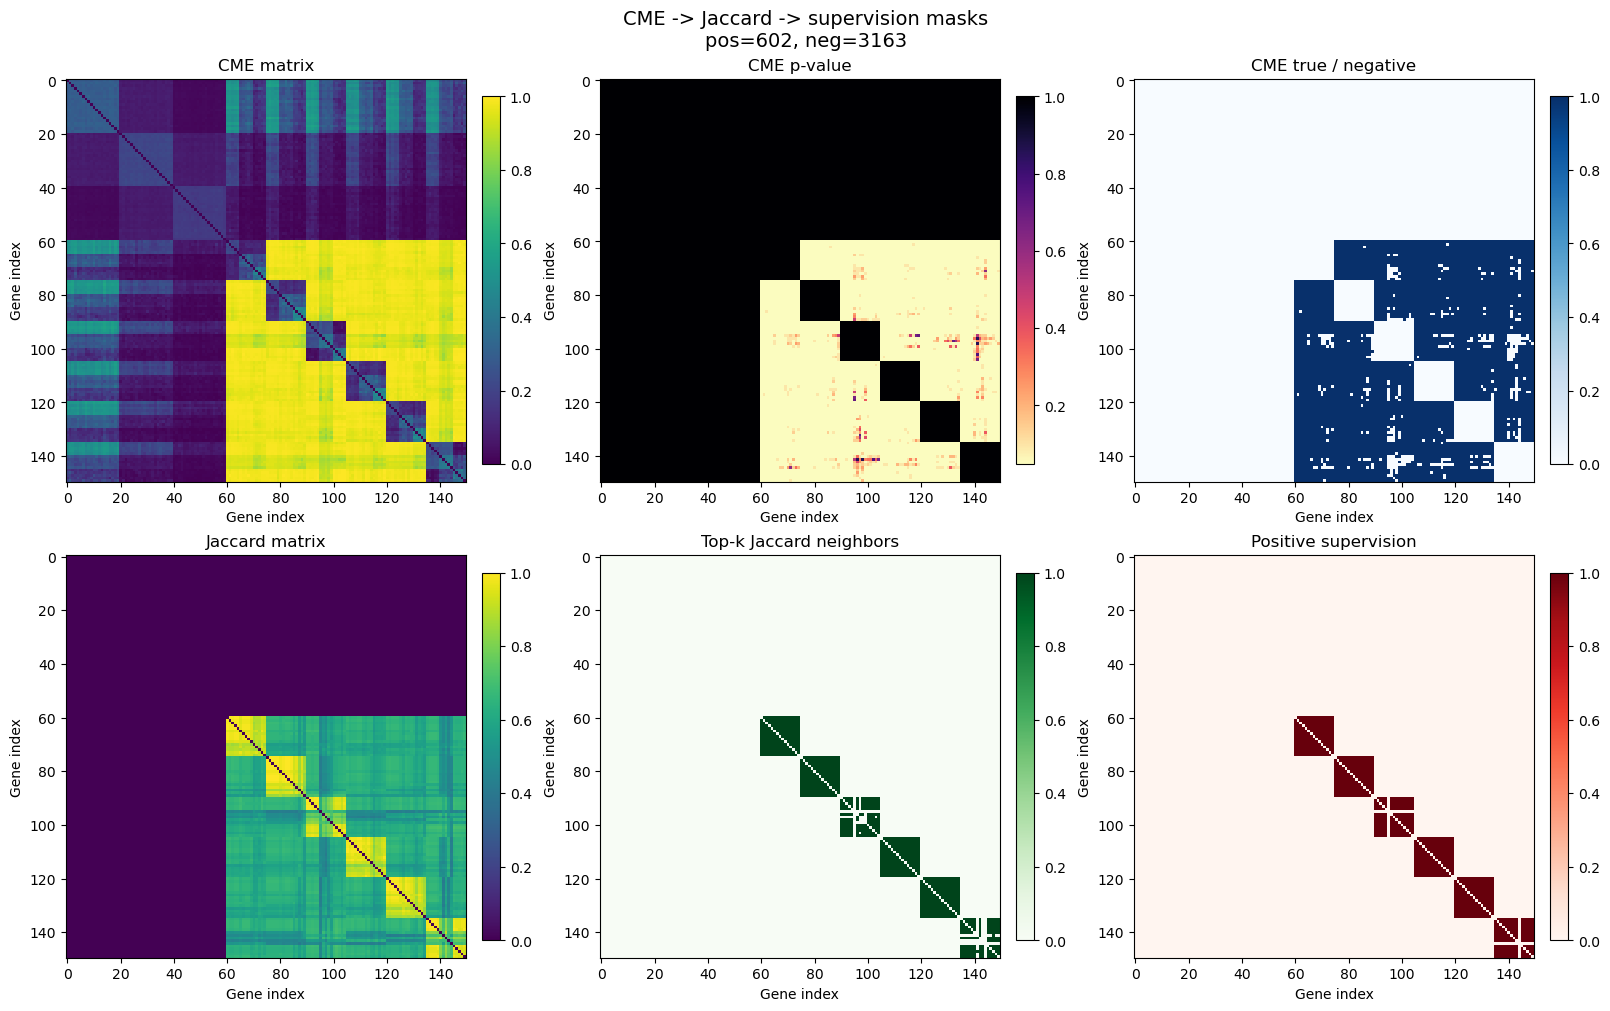

In [12]:
expression = load_expression_from_h5ad(
    ADATA_PATH,
    num_genes=num_genes,
)
cme_matrix = compute_cme_matrix(expression.matrix, normalize=False, use_numba=True)
pval_matrix = compute_cme_pvalues(
    expression.matrix,
    cme_matrix,
    n_permutations=n_permutations,
    seed=seed,
    use_numba=True,
)

supervision = build_supervision_from_cme(
    cme_matrix,
    pval_matrix,
    cme_threshold=t_CME,
    pvalue_threshold=t_p,
    jaccard_threshold=t_Jaccard,
    top_k=k_Jaccard,
)

pos_mask = torch.from_numpy(supervision.positive_mask)
neg_mask = torch.from_numpy(supervision.negative_mask)
supervision.stats

plot_cme_supervision_heatmaps(
    cme_matrix=cme_matrix,
    pval_matrix=pval_matrix,
    supervision=supervision,
    save_path=REPO_ROOT / f"results/{RESULT_PREFIX}_cme_supervision_heatmaps.png",
    show=True,
);


Epoch 1/10000, Loss: 0.129254758, pos(>= 0.5): 0.109268934, neg(->0): 0.018257910, Entropy: 1.7279
Epoch 100/10000, Loss: 0.014145790, pos(>= 0.5): 0.002266038, neg(->0): 0.010732431, Entropy: 1.1473
Epoch 200/10000, Loss: 0.010562994, pos(>= 0.5): 0.001744578, neg(->0): 0.007741548, Entropy: 1.0769
Epoch 300/10000, Loss: 0.000914425, pos(>= 0.5): 0.000000000, neg(->0): 0.000020337, Entropy: 0.8941
Epoch 400/10000, Loss: 0.000850551, pos(>= 0.5): 0.000000000, neg(->0): 0.000003245, Entropy: 0.8473
Epoch 500/10000, Loss: 0.000800230, pos(>= 0.5): 0.000000000, neg(->0): 0.000001490, Entropy: 0.7987
Epoch 600/10000, Loss: 0.000749222, pos(>= 0.5): 0.000000000, neg(->0): 0.000000953, Entropy: 0.7483
Epoch 700/10000, Loss: 0.000697893, pos(>= 0.5): 0.000000000, neg(->0): 0.000000753, Entropy: 0.6971
Epoch 800/10000, Loss: 0.000647172, pos(>= 0.5): 0.000000000, neg(->0): 0.000000670, Entropy: 0.6465
Epoch 900/10000, Loss: 0.000597888, pos(>= 0.5): 0.000000000, neg(->0): 0.000000630, Entropy:

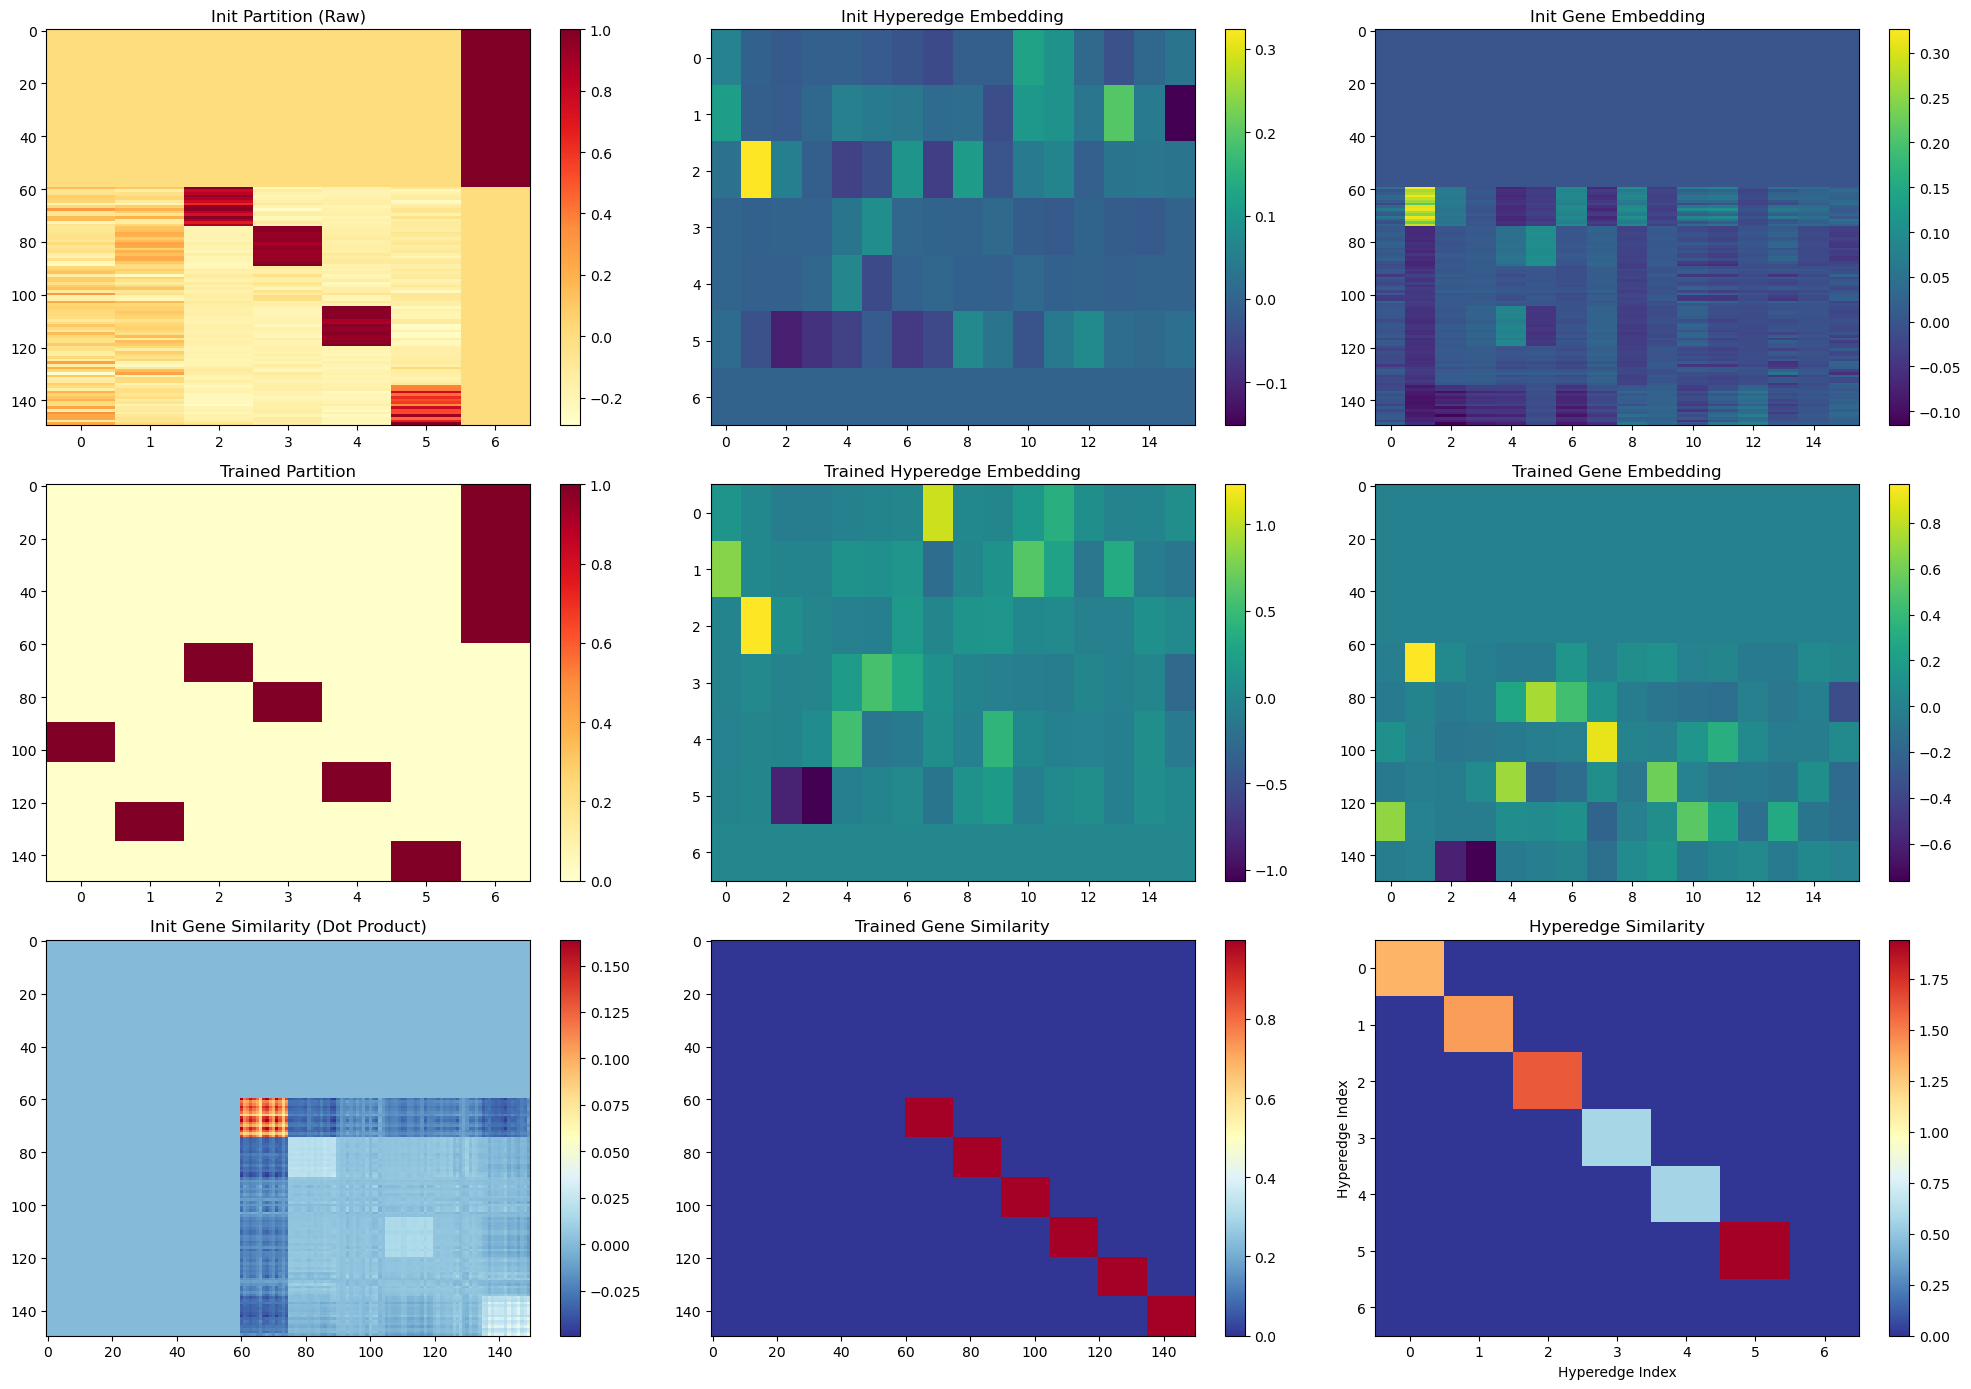

In [13]:
# ===== 正负监督 -> 超边 gene modules =====
result = run_supervised_hyperedges(
    adata=adata,
    pos_mask=pos_mask,
    neg_mask=neg_mask,
    partial_pos_mask=None,
    num_genes=num_genes,
    num_hyperedges=num_hyperedges,
    use_unassigned_hyperedge=True,
    pos_strength=0.5,
    neg_strength=0.0,
    epochs=10000,
    lr=0.016,
    entropy_strength=0.001,
    ranges_map=None,
    device="auto",
    seed=seed,
)

partition = result.partition
hyperedge_emb = result.hyperedge_emb
gene_emb = result.gene_emb
losses = result.losses

summarize_unassigned_genes(result)

plot_run_summary(result);


## ✅ 基因模块识别准确率：**100.00%**

{'overall_accuracy_percent': '100.00%',
 'correct_genes': 90,
 'evaluable_genes': 90}

{'num_modules': 6,
 'num_nodes_with_empty': 7,
 'empty_node_index': 6,
 'root_index': 6,
 'root_is_empty_node': True,
 'cme_threshold': 0.66,
 'mutex_edges': 15,
 'complement_edges': 6,
 'tree_edges': 6,
 'empty_modules': 0,
 'assignment': 'argmax',
 'aggregation': 'sum',
 'child_strategy': 'max_degree_ties',
 'assignment_total_correct': 90,
 'assignment_total_evaluable': 90,
 'weighted_assignment_accuracy': 1.0}

,node_index,hyperedge,num_genes,evaluable_genes,identified_module,identified_count,accuracy,missing_reference,label_counts
0,0,0,15,15,A3,15,1.0,0,{'A3': 15}
1,1,1,15,15,B2,15,1.0,0,{'B2': 15}
2,2,2,15,15,A1,15,1.0,0,{'A1': 15}
3,3,3,15,15,A2,15,1.0,0,{'A2': 15}
4,4,4,15,15,B1,15,1.0,0,{'B1': 15}
5,5,5,15,15,B3,15,1.0,0,{'B3': 15}


{'num_nodes': 7,
 'tree_edges': 6,
 'tree_has_all_nodes': True,
 'tree_edge_count_ok': True,
 'root_is_empty_node': True,
 'mutex_graph_is_symmetric': True,
 'complement_graph_is_symmetric': True}

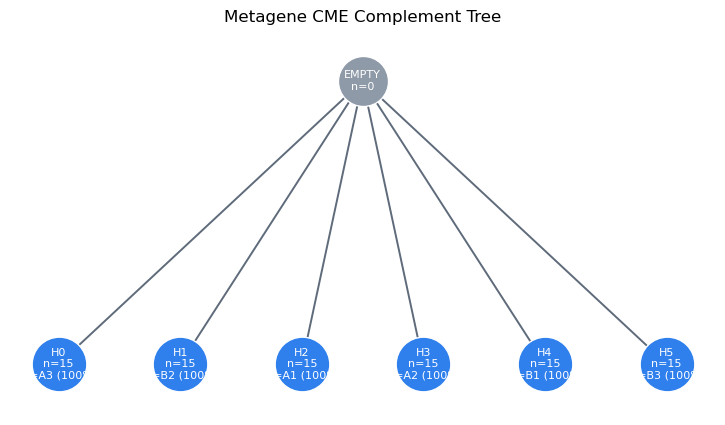

In [14]:
# ===== 超边 metagene CME -> 互斥图补图 -> 度优先树 =====
metagene_tree = build_metagene_tree_from_result(
    result,
    expression.matrix,
    adata=adata,
    gene_names=expression.gene_names,
    reference_column="gene_module",
    cme_threshold=t_CME,
    assignment="argmax",
    aggregation="sum",
    child_strategy="max_degree_ties",
)

tree_validation = validate_metagene_tree_result(metagene_tree)
assert tree_validation["tree_has_all_nodes"]
assert tree_validation["tree_edge_count_ok"]
assert tree_validation["root_is_empty_node"]

overall_accuracy = metagene_tree.stats.get("weighted_assignment_accuracy")
overall_accuracy_summary = {
    "overall_accuracy_percent": None if overall_accuracy is None else f"{overall_accuracy:.2%}",
    "correct_genes": metagene_tree.stats.get("assignment_total_correct"),
    "evaluable_genes": metagene_tree.stats.get("assignment_total_evaluable"),
}

from IPython.display import display, Markdown

acc = overall_accuracy_summary["overall_accuracy_percent"]
display(Markdown(f"## ✅ 基因模块识别准确率：**{acc}**"))

display(overall_accuracy_summary)
display(metagene_tree.stats)
display(pd.DataFrame(metagene_tree.module_assignment_table))
display(tree_validation)

fig = plot_metagene_tree(
    metagene_tree,
    save_path=REPO_ROOT / f"results/{RESULT_PREFIX}_metagene_cme_tree.png",
)


In [15]:
# ===== metagene score -> cell type 判断 =====
if "cell_type" not in adata.obs:
    raise ValueError("adata.obs 里没有 'cell_type' 列，不能计算细胞类型准确度。")

cell_type_result = score_cell_types_from_metagene_tree(
    metagene_tree,
    adata=adata,
    obs_column="cell_type",
)
cell_type_accuracy_summary = {
    "cell_type_accuracy": cell_type_result.stats["cell_type_accuracy"],
    "cell_type_accuracy_percent": f"{cell_type_result.stats['cell_type_accuracy']:.2%}",
    "correct_cells": cell_type_result.stats["cell_type_total_correct"],
    "evaluable_cells": cell_type_result.stats["cell_type_total_evaluable"],
}
acc_pct = f"{cell_type_result.stats['cell_type_accuracy']:.2%}"
display(Markdown(f"## ✅ 细胞类型识别准确率：**{acc_pct}**"))
display(cell_type_accuracy_summary)
display(pd.DataFrame(cell_type_result.metagene_cell_type_table))


# ===== subtype -> parent type 从属关系判断 =====
hierarchy_result = score_cell_hierarchy_from_cell_types(cell_type_result)
hierarchy_accuracy_summary = {
    "hierarchy_accuracy": hierarchy_result.stats["hierarchy_accuracy"],
    "hierarchy_accuracy_percent": f"{hierarchy_result.stats['hierarchy_accuracy']:.2%}",
    "correct_cells": hierarchy_result.stats["hierarchy_total_correct"],
    "evaluable_cells": hierarchy_result.stats["hierarchy_total_evaluable"],
}
hierarchy_acc_pct = f"{hierarchy_result.stats['hierarchy_accuracy']:.2%}"
display(Markdown(f"## ✅ 细胞从属关系识别准确率：**{hierarchy_acc_pct}**"))
display(hierarchy_accuracy_summary)
display(pd.DataFrame(hierarchy_result.hierarchy_relation_table))


## ✅ 细胞类型识别准确率：**100.00%**

{'cell_type_accuracy': 1.0,
 'cell_type_accuracy_percent': '100.00%',
 'correct_cells': 900,
 'evaluable_cells': 900}

,node_index,hyperedge,identified_cell_type,mean_score,assigned_cells,evaluable_assigned_cells,correct_assigned_cells,assigned_accuracy
0,0,0,A3,82.046669,150,150,150,1.0
1,1,1,B2,74.779999,150,150,150,1.0
2,2,2,A1,79.346664,150,150,150,1.0
3,3,3,A2,68.893333,150,150,150,1.0
4,4,4,B1,69.073334,150,150,150,1.0
5,5,5,B3,74.633331,150,150,150,1.0


## ✅ 细胞从属关系识别准确率：**100.00%**

{'hierarchy_accuracy': 1.0,
 'hierarchy_accuracy_percent': '100.00%',
 'correct_cells': 900,
 'evaluable_cells': 900}

,predicted_cell_type,predicted_parent_type,assigned_cells,correct_parent_cells,reference_parent_counts,parent_accuracy
0,A1,A,150,150,{'A': 150},1.0
1,A2,A,150,150,{'A': 150},1.0
2,A3,A,150,150,{'A': 150},1.0
3,B1,B,150,150,{'B': 150},1.0
4,B2,B,150,150,{'B': 150},1.0
5,B3,B,150,150,{'B': 150},1.0
